# Seq2Seq Translation

Seq2Seq(Sequence-to-Sequence) 모델은 2014년에 구글브레인 연구원(**일리아 슈츠케버(Ilya Sutskever)**, **오리올 비냐스(Oriol Vinyals)**, 그리고 **콕 V. 레(Quoc V. Le)**)들에 의해 개발되었다.

입력 시퀀스를 다른 도메인의 출력 시퀀스로 변환하는 딥러닝 모델이다.

주로 자연어 처리(NLP)에서 사용되며, 기계 번역, 텍스트 요약, 음성 인식 등 다양한 작업에서 활용된다.

![](https://d.pr/i/Q0wWs0+)

**주요 발표 내용 및 배경**

| **항목**    | **내용**                                               |
|-----------|------------------------------------------------------|
| **발표 시기** | 2014년                                                |
| **논문 제목** | "Sequence to Sequence Learning with Neural Networks" |
| **연구자**   | Ilya Sutskever, Oriol Vinyals, Quoc V. Le            |
| **소속**    | 구글 브레인(Google Brain)                                 |
| **논문 링크** | [논문 링크](https://arxiv.org/abs/1409.3215)             |

**Seq2Seq 모델의 주요 기여**

1. **기계 번역의 혁신**: 기존의 통계적 기계 번역(SMT) 방식에 비해 신경망 기계번역(NMT)의 첫 주자로, 자연스럽고 유연한 번역을 가능하게 함.
2. **인코더-디코더 아키텍처**: 입력 시퀀스를 인코더가 고정된 벡터로 인코딩하고, 디코더가 이를 기반으로 출력 시퀀스를 생성하는 구조를 도입.
3. **후속 발전**: Seq2Seq 이후 어텐션 메커니즘 및 트랜스포머 아키텍처의 등장으로 더욱 강력한 시퀀스 처리 모델이 개발될 수 있었음.


**구조**
1. **인코더 (Encoder)**
   - 입력 시퀀스를 고정된 크기의 벡터로 인코딩한다.
   - 주로 RNN(LSTM, GRU) 구조를 사용한다.
   - 입력 시퀀스를 시계열로 처리하며 마지막 은닉 상태(hidden state)를 디코더로 전달한다.

2. **디코더 (Decoder)**
   - 인코더에서 전달받은 컨텍스트 벡터(context vector)와 은닉 상태를 기반으로 출력 시퀀스를 생성한다.
   - 디코더는 순차적으로 다음 토큰을 예측하며, 이전에 생성된 토큰을 입력으로 사용한다.


**학습 과정**

![https://medium.com/geekculture/neural-machine-translation-using-sequence-to-sequence-model-164a5905bcd7](https://d.pr/i/HR5Vt6+)


![https://medium.com/geekculture/neural-machine-translation-using-sequence-to-sequence-model-164a5905bcd7](https://d.pr/i/OPZueF+)


1. **Teacher Forcing**
   - 학습 중 디코더에 이전에 생성된 예측값이 아니라 실제 정답 토큰을 입력으로 제공하여 빠르고 안정적인 학습을 돕는다.
    
    ![](https://d.pr/i/4w651h+)

2. **손실 함수**
   - 출력 시퀀스의 각 토큰에 대해 예측값과 실제값의 차이를 계산한다.
   - 보통 `CrossEntropyLoss`를 사용한다.


**추론 과정**
- 입력 시퀀스를 인코더에 전달하여 컨텍스트 벡터를 생성한다.
- 디코더는 컨텍스트 벡터와 이전 단계의 출력값(시작 시 `<start>` 토큰)을 기반으로 반복적으로 출력값을 생성한다.
- 종료 조건은 `<end>` 토큰이 생성되거나 사전에 정의된 최대 길이에 도달할 때이다.

**장점과 한계**
- **장점**: 시퀀스 길이가 가변적이므로 다양한 길이의 입력과 출력 처리  가능.
- **한계**: 고정된 크기의 컨텍스트 벡터에 정보를 모두 압축하면 긴 시퀀스에서 정보 손실이 발생할 수 있다.

**확장 모델**
1. **Attention Mechanism**
   - 인코더의 모든 은닉 상태를 활용하여 디코더가 출력 시점마다 중요한 입력 토큰에 집중하도록 한다.
   - 성능을 크게 향상시키며, Transformer 기반 모델의 등장 배경이 된다.

2. **Transformer**
   - RNN 없이 Attention 메커니즘만을 사용하며 Seq2Seq의 최신 발전형이다.


## 데이터/임베딩 준비

https://www.manythings.org/anki/

https://nlp.stanford.edu/projects/glove/

In [ ]:
# 데이터 준비
eng_inputs = []     # 인코더 입력용
kor_inputs = []     # 디코더 입력용(teacher-forcing)
kor_targets = []    # 디코더 출력용

with open('data/kor.txt', 'r', encoding='utf-8') as f:
    for line in f:
        english, korean, attribution = line.split('\t')

        # 시작/종료 토큰 연결 시 공백
        kor_input = '<sos> ' + korean
        kor_target = korean + ' <eos>'

        eng_inputs.append(english)
        kor_inputs.append(kor_input)
        kor_targets.append(kor_target)

print(len(eng_inputs), len(kor_inputs), len(kor_targets))

6394 6394 6394


In [ ]:
# 일부 내용 확인
print(eng_inputs[1100:1105])
print(kor_inputs[1100:1105])
print(kor_targets[1100:1105])

['Tom drinks beer.', 'Tom got retired.', 'Tom is a Muslim.', 'Tom is a Muslim.', 'Tom is a runner.']
['<sos> 톰은 맥주를 마신다.', '<sos> 톰은 은퇴했어.', '<sos> 톰은 무슬림이다.', '<sos> 톰은 이슬람교 신자다.', '<sos> 톰은 달리기 선수야.']
['톰은 맥주를 마신다. <eos>', '톰은 은퇴했어. <eos>', '톰은 무슬림이다. <eos>', '톰은 이슬람교 신자다. <eos>', '톰은 달리기 선수야. <eos>']


## 데이터 전처리

In [ ]:
# 전역 변수 선언
BATCH_SIZE = 64
MAX_VOCAB_SIZE = 10000
EMBEDDING_DIM = 100
HIDDEN_DIM = 512

In [ ]:
# 영문 토크나이저
from tensorflow.keras.preprocessing.text import Tokenizer

eng_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
eng_tokenizer.fit_on_texts(eng_inputs)
eng_sentences = eng_tokenizer.texts_to_sequences(eng_inputs)

print(eng_sentences[1100:1105])
print(eng_inputs[1100:1105])

[[2, 796, 504], [2, 130, 1439], [2, 6, 7, 1440], [2, 6, 7, 1440], [2, 6, 7, 2020]]
['Tom drinks beer.', 'Tom got retired.', 'Tom is a Muslim.', 'Tom is a Muslim.', 'Tom is a runner.']


In [ ]:
# 단어 사전의 사전 수, 문장 최대 길이 확인
eng_word_index = eng_tokenizer.word_index
eng_num_words = min(MAX_VOCAB_SIZE, len(eng_word_index) + 1)
print(eng_num_words)    # 실제 사용 되는 단어 수

eng_max_len = max([len(seq) for seq in eng_sentences])
print(eng_max_len)      # 실제 최대 문장 길이

3377
101


In [ ]:
# 한국어 tokenizer
# filters 매개변수를 ""로 설정하여 <sos> <eos> 토큰 보전
kor_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters="")
kor_tokenizer.fit_on_texts(kor_inputs + kor_targets)
kor_input_sentences = kor_tokenizer.texts_to_sequences(kor_inputs)
kor_target_sentences = kor_tokenizer.texts_to_sequences(kor_targets)

print(kor_input_sentences[1100:1105])
print(kor_target_sentences[1100:1105])
print(kor_inputs[1100:1105])
print(kor_targets[1100:1105])

[[1, 3, 581, 3506], [1, 3, 1684], [1, 3, 3507], [1, 3, 3508, 3509], [1, 3, 1804, 3510]]
[[3, 581, 3506, 2], [3, 1684, 2], [3, 3507, 2], [3, 3508, 3509, 2], [3, 1804, 3510, 2]]
['<sos> 톰은 맥주를 마신다.', '<sos> 톰은 은퇴했어.', '<sos> 톰은 무슬림이다.', '<sos> 톰은 이슬람교 신자다.', '<sos> 톰은 달리기 선수야.']
['톰은 맥주를 마신다. <eos>', '톰은 은퇴했어. <eos>', '톰은 무슬림이다. <eos>', '톰은 이슬람교 신자다. <eos>', '톰은 달리기 선수야. <eos>']


In [ ]:
# 한국어 단어 개수/ 문장길이
kor_num_words = min(MAX_VOCAB_SIZE, len(kor_tokenizer.word_index) + 1)
print(kor_num_words)    # 실제 사용 되는 단어 수
kor_max_len = max([len(seq) for seq in kor_input_sentences])
print(kor_max_len)      # 실제 최대 문장 길이

8895
90


In [ ]:
# 패딩 처리
from tensorflow.keras.preprocessing.sequence import pad_sequences

encoder_inputs = pad_sequences(eng_sentences, maxlen=eng_max_len, padding='pre')
decoder_inputs = pad_sequences(kor_input_sentences, maxlen=kor_max_len, padding='post')
decoder_targets = pad_sequences(kor_target_sentences, maxlen=kor_max_len, padding='post')

print(encoder_inputs.shape)
print(decoder_inputs.shape)
print(decoder_targets.shape)

(6394, 101)
(6394, 90)
(6394, 90)


In [ ]:
print(encoder_inputs[1100])
print(decoder_inputs[1100])
print(decoder_targets[1100])

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   2 796 504]
[   1    3  581 3506    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
[   3  581 3506    2    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0

## 데이터셋/데이터로더

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np

class NMTDataset(Dataset):
    def __init__(self, encoder_inputs, decoder_inputs, decoder_targets):
        super().__init__()
        self.encoder_inputs = encoder_inputs
        self.decoder_inputs = decoder_inputs
        self.decoder_targets = decoder_targets

    def __len__(self):
        return len(self.encoder_inputs)

    def __getitem__(self, index):
        return (
            torch.tensor(self.encoder_inputs[index], dtype=torch.long),
            torch.tensor(self.decoder_inputs[index], dtype=torch.long),
            torch.tensor(self.decoder_targets[index], dtype=torch.long),
        )

train_index, val_index = train_test_split(np.arange(len(encoder_inputs)), test_size=0.2, random_state=42)

train_dataset = NMTDataset(
    encoder_inputs[train_index],
    decoder_inputs[train_index],
    decoder_targets[train_index]
)

val_dataset = NMTDataset(
    encoder_inputs[val_index],
    decoder_inputs[val_index],
    decoder_targets[val_index]
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(len(train_dataset), len(val_dataset))     # 테스트용/검증용 데이터 수
print(len(train_loader), len(val_loader))       # 테스트용/검증용 step 수

5115 1279
80 20


## Glove 사전 학습 임베딩 사용

In [ ]:
with open('data/glove.6B.100d.txt', 'r', encoding='utf-8') as f:
    eng_embedding_dict = {}
    for line in f:
        word, *vector = line.split()
        vector = np.array(vector, dtype=np.float32)
        eng_embedding_dict[word] = vector

    vocab_size = min(MAX_VOCAB_SIZE, len(eng_tokenizer.word_index) + 1)
    eng_embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

    for word, i in eng_tokenizer.word_index.items():
        vec = eng_embedding_dict.get(word)

        if vec is not None:
            eng_embedding_matrix[i] = vec
        else:
            eng_embedding_matrix[i] = np.random.rand(EMBEDDING_DIM)

In [ ]:
import pandas as pd

index_ = [''] + list(eng_tokenizer.word_index.keys())
pd.DataFrame(eng_embedding_matrix, index=index_)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
i,-0.046539,0.619660,0.56647,-0.465840,-1.189000,0.445990,0.066035,0.319100,0.146790,-0.22119,...,-0.323430,-0.431210,0.41392,0.283740,-0.709310,0.150030,-0.215400,-0.376160,-0.032502,0.806200
tom,-0.583880,-0.469400,0.16855,-1.670300,-0.116010,0.048738,-0.342010,-0.376910,-0.953080,-0.88260,...,0.264290,0.337860,0.35791,0.549010,0.006725,0.281580,0.343730,0.137040,0.089572,-0.542770
to,-0.189700,0.050024,0.19084,-0.049184,-0.089737,0.210060,-0.549520,0.098377,-0.201350,0.34241,...,-0.131340,0.058617,-0.31869,-0.614190,-0.623930,-0.415480,-0.038175,-0.398040,0.476470,-0.159830
you,-0.498860,0.766020,0.89751,-0.785470,-0.685500,0.626090,-0.396550,0.349130,0.333340,-0.45233,...,-0.327380,-0.009343,0.47205,-0.516910,-0.591760,-0.323430,0.200520,-0.411790,0.405390,0.785040
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
whom,0.341680,0.545720,-0.15683,-0.205450,-0.199470,0.389270,-0.017266,-0.244750,0.124760,-0.34392,...,0.142210,-0.556420,0.45764,-0.243960,-1.146800,0.330140,-0.900430,-0.014213,0.161420,-0.444830
intimately,-0.416930,0.131300,0.50615,0.034870,0.255630,0.409070,0.234080,-0.574340,0.293270,0.14061,...,-0.636420,0.066336,-0.44926,-1.350100,0.381640,-0.051961,-0.425590,-0.667450,0.009747,0.061855
millions,0.622040,1.063600,0.13146,-0.203880,0.555570,0.443570,-0.524210,0.040587,0.470640,-0.53788,...,-0.063191,-0.111260,0.66609,-0.972050,-0.558910,-0.837910,-0.147160,0.862920,0.302910,-0.225640
inhabit,-0.927750,0.738860,0.69884,0.138580,0.020592,0.521490,-0.541050,0.501790,0.206630,-0.51982,...,0.491800,-0.235440,0.48243,-0.714400,-0.378190,0.271660,-1.243600,-0.288030,0.065840,0.053163


## 모델 설계

In [ ]:
import torch
import torch.nn as nn

# Encoder Class
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, embedding_matrix=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        x = self.embedding(x)
        output, (hidden, cell) = self.lstm(x)
        return hidden, cell

# Decoder Class
class DecoderTeacherForcing(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, enc_hidden, enc_cell):
        x = self.embedding(x)
        # encoder가 출력한 hidden/cell 초기화
        output, (hidden, cell) = self.lstm(x, (enc_hidden, enc_cell))
        x = self.fc(output)
        return x, hidden, cell

# Seq2Seq class
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, encoder_inputs, decoder_inputs):
        enc_hidden, enc_cell = self.encoder(encoder_inputs)
        outputs, _, _ = self.decoder(decoder_inputs, enc_hidden, enc_cell)
        return outputs

encoder = Encoder(eng_num_words, EMBEDDING_DIM, HIDDEN_DIM, eng_embedding_matrix)
decoder = DecoderTeacherForcing(kor_num_words, EMBEDDING_DIM, HIDDEN_DIM)
model = Seq2Seq(encoder, decoder)
model

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(3377, 100, padding_idx=0)
    (lstm): LSTM(100, 512, batch_first=True)
  )
  (decoder): DecoderTeacherForcing(
    (embedding): Embedding(8895, 100, padding_idx=0)
    (lstm): LSTM(100, 512, batch_first=True)
    (fc): Linear(in_features=512, out_features=8895, bias=True)
  )
)

## 모델 학습

In [ ]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

encoder = Encoder(eng_num_words, EMBEDDING_DIM, HIDDEN_DIM, eng_embedding_matrix)
decoder = DecoderTeacherForcing(kor_num_words, EMBEDDING_DIM, HIDDEN_DIM)
model = Seq2Seq(encoder, decoder).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=0) # 패딩토큰 손실계산
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 학습
epochs = 100

train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range(epochs):
    model.train()
    train_loss, train_correct, train_tokens = 0, 0, 0

    for enc_inputs, dec_inputs, dec_targets in train_loader:
        enc_inputs = enc_inputs.to(device)
        dec_inputs = dec_inputs.to(device)
        dec_targets = dec_targets.to(device)

        optimizer.zero_grad()
        outputs = model(enc_inputs, dec_inputs)

        # outputs 구조 (batch, seq_len, vocab_size)
        outputs = outputs.view(-1, outputs.size(-1)) # (batch * seq_len, vocab_size)

        # target 구조 (batch, seq_len)
        dec_targets = dec_targets.view(-1)

        # CELoss가 기대하는 구조 (logits, target)
        # - logits (batch, vocab_size)
        # - target (batch)
        loss = criterion(outputs, dec_targets)
        loss.backward()
        optimizer.step()

        # 학습상태 기록
        preds = outputs.argmax(dim=1)
        train_loss += loss.detach().cpu().item()
        mask = dec_targets != 0             # 패딩이 아닌 부분만 계산
        correct = (preds == dec_targets) & mask
        train_correct += correct.sum().detach().cpu().item()
        train_tokens += mask.sum().detach().cpu().item()

    train_loss /= len(train_loader)
    train_acc = train_correct / train_tokens
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # 검증
    model.eval()
    val_loss, val_correct, val_tokens = 0, 0, 0
    with torch.no_grad():

        for enc_inputs, dec_inputs, dec_targets in val_loader:
            enc_inputs = enc_inputs.to(device)
            dec_inputs = dec_inputs.to(device)
            dec_targets = dec_targets.to(device)

            optimizer.zero_grad()
            outputs = model(enc_inputs, dec_inputs)

            outputs = outputs.view(-1, outputs.size(-1)) # (batch * seq_len, vocab_size)
            dec_targets = dec_targets.view(-1)

            loss = criterion(outputs, dec_targets)

            # 검증상태 기록
            preds = outputs.argmax(dim=1)
            val_loss += loss.detach().cpu().item()
            mask = dec_targets != 0 # 패딩이 아닌 부분만 계산
            correct = (preds == dec_targets) & mask
            val_correct += correct.sum().detach().cpu().item()
            val_tokens += mask.sum().detach().cpu().item()

        val_loss /= len(val_loader)
        val_acc = val_correct / val_tokens
        val_losses.append(val_loss)
        val_accs.append(val_acc)

    print(f'Epoch({epoch + 1}/{epochs}): '
          f'TrainLoss {train_loss:.4f}, '
          f'TrainAcc {train_acc:.4f}, '
          f'ValLoss {val_loss:.4f}, '
          f'ValAcc {val_acc:.4f}')

cuda
Epoch(1/100): TrainLoss 7.1012, TrainAcc 0.2118, ValLoss 6.7884, ValAcc 0.2220
Epoch(2/100): TrainLoss 6.2912, TrainAcc 0.2199, ValLoss 6.7571, ValAcc 0.2228
Epoch(3/100): TrainLoss 5.9162, TrainAcc 0.2289, ValLoss 6.6324, ValAcc 0.2434
Epoch(4/100): TrainLoss 5.4295, TrainAcc 0.2462, ValLoss 6.5386, ValAcc 0.2507
Epoch(5/100): TrainLoss 4.8715, TrainAcc 0.2669, ValLoss 6.5318, ValAcc 0.2635
Epoch(6/100): TrainLoss 4.2701, TrainAcc 0.2984, ValLoss 6.4502, ValAcc 0.2778
Epoch(7/100): TrainLoss 3.6213, TrainAcc 0.3652, ValLoss 6.4428, ValAcc 0.2907
Epoch(8/100): TrainLoss 2.9881, TrainAcc 0.4699, ValLoss 6.4514, ValAcc 0.3001
Epoch(9/100): TrainLoss 2.4190, TrainAcc 0.5707, ValLoss 6.4580, ValAcc 0.3123
Epoch(10/100): TrainLoss 1.9557, TrainAcc 0.6450, ValLoss 6.5005, ValAcc 0.3184
Epoch(11/100): TrainLoss 1.6169, TrainAcc 0.7004, ValLoss 6.5281, ValAcc 0.3232
Epoch(12/100): TrainLoss 1.3550, TrainAcc 0.7460, ValLoss 6.5696, ValAcc 0.3303
Epoch(13/100): TrainLoss 1.1455, TrainAcc 0.

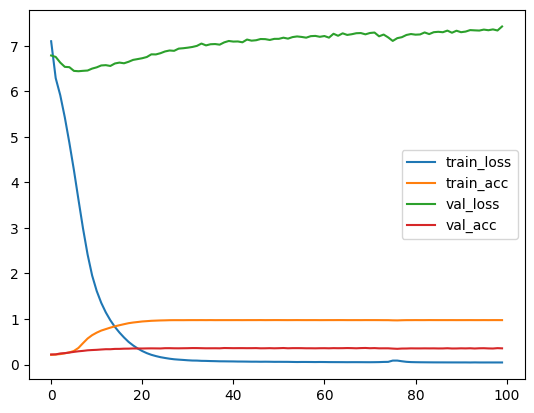

In [ ]:
# 시각화
import matplotlib.pyplot as plt

history_df = pd.DataFrame({
    'train_loss': train_losses,
    'train_acc': train_accs,
    'val_loss': val_losses,
    'val_acc': val_accs
})
history_df.plot()
plt.show()

In [ ]:
# 모델 저장
# 학습이 끝난 모델의 파라미터만 저장한다.
torch.save(model.state_dict(), 'seq2seq_translation_state_dict.pth')

In [ ]:
# 모델 로드
# 저장 된 파라미터를 불러와서 사용할 새 모델 객체를 만든다.

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 학습 때와 동일한 구조의 Encoder, Decoder 생성하여 모델 생성
loaded_encoder = Encoder(eng_num_words, EMBEDDING_DIM, HIDDEN_DIM, eng_embedding_matrix)
loaded_decoder = DecoderTeacherForcing(kor_num_words, EMBEDDING_DIM, HIDDEN_DIM)
loaded_model = Seq2Seq(loaded_encoder, loaded_decoder).to(device)

# 저장 된 가중치를 불러온다
# map_location=device :저장 당시 장치와 현재 실행 장치가 달라도 불러올 수 있도록 하는 옵션
loaded_model.load_state_dict(
    torch.load('seq2seq_translation_state_dict.pth', map_location=device)
)

loaded_model

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(3377, 100, padding_idx=0)
    (lstm): LSTM(100, 512, batch_first=True)
  )
  (decoder): DecoderTeacherForcing(
    (embedding): Embedding(8895, 100, padding_idx=0)
    (lstm): LSTM(100, 512, batch_first=True)
    (fc): Linear(in_features=512, out_features=8895, bias=True)
  )
)

In [ ]:
# 추론 함수
def translate(input_seq, model, kor_tokenizer=kor_tokenizer, max_len=kor_max_len, device=device):
  # 추론 모드 설정
  model.eval()

  # Seq2Seq 내부의 encoder, decoder 분리해서 사용
  # 추론 시에는 decoder_inputs를 넣지 않기 때문
  encoder = model.encoder
  decoder = model.decoder

  # 입력 영어 문장을 변환하고 device로 이동
  # (정수인코딩 & 패딩 처리 되어서 들어올 값으로 가정)
  input_seq = torch.tensor(input_seq, dtype=torch.long).to(device)

  with torch.no_grad():
    # encoder는 영어 문장을 읽고 마지막 hidden state와 cell state를 만든다
    # decoder의 초기 상태 값이 된다
    hidden, cell = encoder(input_seq)

    # 한국어 시작 토큰과 종료 토큰의 id
    sos_index = kor_tokenizer.word_index['<sos>']
    eos_index = kor_tokenizer.word_index['<eos>']

    # decoder의 첫 입력은 항상 <sos>이다
    # shape : (batch_size, seq_len) = (1, 1)
    target_seq = torch.tensor([[sos_index]], dtype=torch.long).to(device)

    output_sentences = []

    # 최대 max_len까지만 단어를 생성하고 중간에 <eos>가 나오면 문장 생성을 종료
    for _ in range(max_len):
      output, hidden, cell = decoder(target_seq, hidden, cell)

      # output shape : (1, seq_len, kor_vocab_size)
      output = output.squeeze(1)   # (1, kor_vocab_size)

      # 가장 점수가 높은 단어 id를 선택
      pred = output.argmax(dim=-1).item()

      # 종료 토큰이 나오면 번역 종료
      if pred == eos_index:
        break

      # 예측한 id를 한국어 토큰으로 변환하고 문장에 추가
      kor_token = kor_tokenizer.index_word.get(pred, '')
      output_sentences.append(kor_token)

      # 방금 예측한 단어를 다음 시점의 decoder 입력으로 사용한다
      # Auto-Regressive 방식
      target_seq = torch.tensor([[pred]], dtype=torch.long).to(device)

  return ' '.join(output_sentences)


In [ ]:
# 저장 후 로드한 모델로 번역 테스트
index = 1000
print('입력 영어 문장')
print(eng_inputs[index])

input_seq = encoder_inputs[index]
print('정수 인코딩 된 입력:')
print(input_seq)

print('번역 결과')
print(translate([input_seq], loaded_model))

입력 영어 문장
He loves trains.
정수 인코딩 된 입력:
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
   15  335 1428]
번역 결과
그는 열차를 좋아한다.


In [ ]:
# 랜덤 샘플 번역 테스트
for _ in range(5):
  i = np.random.choice(len(eng_inputs))
  input_seq = encoder_inputs[i]
  kor_sentence = translate([input_seq], loaded_model)

  print('ENG:', eng_inputs[i])
  print('KOR(정답):', kor_inputs[i])
  print('KOR(예측):', kor_sentence)

ENG: I've fed the fish.
KOR(정답): <sos> 물고기한테 먹이를 줬어.
KOR(예측): 감자에 치즈를 녹이자.
ENG: Everything that lives perishes.
KOR(정답): <sos> 살아있는 모든 것은 죽는다.
KOR(예측): 저 빌딩에는 아무도 살지 않는다.
ENG: I know a lot about this computer.
KOR(정답): <sos> 난 이 컴퓨터에 대해 많은 것을 알고있어.
KOR(예측): 난 이 컴퓨터에 대해 많은 것을 알고있어.
ENG: Tom yawned.
KOR(정답): <sos> 톰이 하품했어.
KOR(예측): 톰이 하품했어.
ENG: It isn't fair to keep Tom in the dark.
KOR(정답): <sos> 톰을 아무것도 모르도록 두는 건 공정하지 않아.
KOR(예측): 톰을 아무것도 모르도록 두는 건 공정하지 않아.
